<a href="https://colab.research.google.com/github/GyanAnargya/Kumpulan-Hasil-Tugas/blob/main/24_preprocessing%26deteksiQRS_analisisHRVsinyalECG__Revina_Agnanta.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Kodingan Pre-processing Sinyal ECG**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


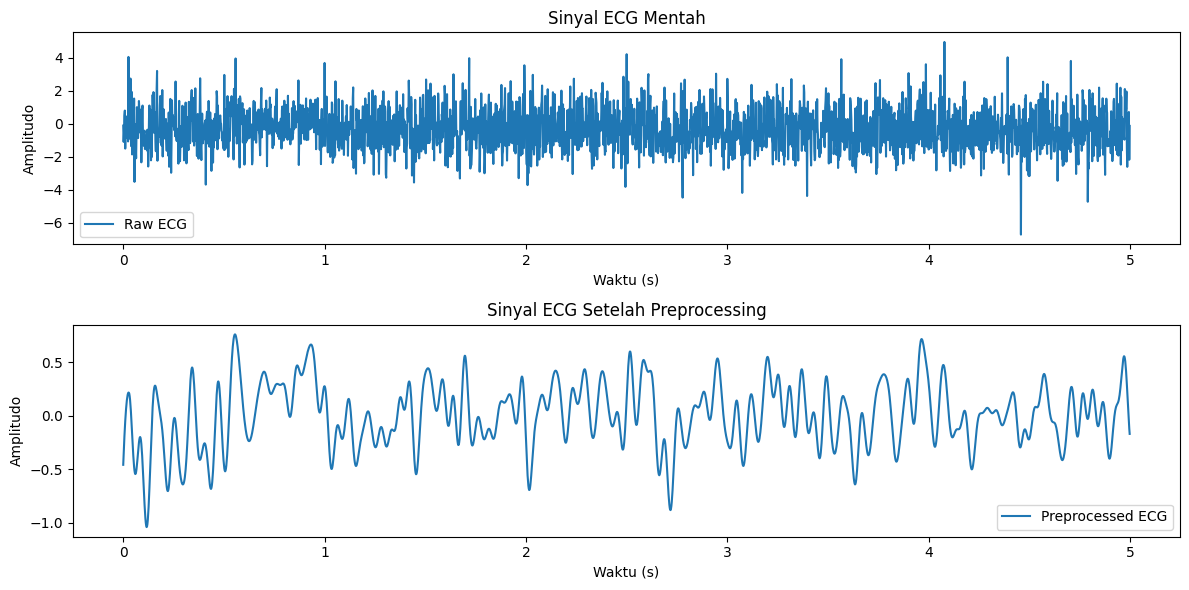

In [ ]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt


def load_ecg_from_array(ecg_array, fs=500):
    return np.asarray(ecg_array, dtype=float), fs


def load_ecg_from_csv(path, fs=500, column=None):
    df = pd.read_csv(path, header=0 if column else None)
    data = df[column].values if column else df.iloc[:, 0].values
    return data.astype(float), fs


def butter_highpass(cutoff, fs, order=2):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='highpass')
    return b, a


def butter_lowpass(cutoff, fs, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype='lowpass')
    return b, a


def notch_filter(freq, fs, quality=30):
    nyq = 0.5 * fs
    w0 = freq / nyq
    b, a = signal.iirnotch(w0, quality)
    return b, a


def savgol_denoise(signal_in, window_length=31, polyorder=3):
    return signal.savgol_filter(signal_in, window_length, polyorder)


def preprocess_ecg(ecg_raw, fs,
                   lowcut=0.5, highcut=40.0,
                   notch_freq=50.0,
                   hp_order=2, lp_order=4,
                   sg_window=31, sg_poly=3):

    b1, a1 = butter_highpass(0.5, fs, order=2)
    x1 = signal.filtfilt(b1, a1, ecg_raw)

    b2, a2 = butter_lowpass(20, fs, order=4)
    x2 = signal.filtfilt(b2, a2, x1)

    b3, a3 = notch_filter(50, fs)
    x3 = signal.filtfilt(b3, a3, x2)

    x4 = signal.detrend(x3)

    ecg_pre = savgol_denoise(x4, window_length=sg_window, polyorder=sg_poly)
    return ecg_pre


def plot_before_after(ecg_raw, ecg_pre, fs, start_sec=0, duration_sec=5):
    start_idx = int(start_sec * fs)
    end_idx = start_idx + int(duration_sec * fs)
    t = np.arange(start_idx, end_idx) / fs

    plt.figure(figsize=(12, 6))
    plt.subplot(2, 1, 1)
    plt.plot(t, ecg_raw[start_idx:end_idx], label='Raw ECG')
    plt.title('Sinyal ECG Mentah')
    plt.xlabel('Waktu (s)')
    plt.ylabel('Amplitudo')
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(t, ecg_pre[start_idx:end_idx], label='Preprocessed ECG')
    plt.title('Sinyal ECG Setelah Preprocessing')
    plt.xlabel('Waktu (s)')
    plt.ylabel('Amplitudo')
    plt.legend()

    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print('Google Drive mounted.')
    except ImportError:
        print('Not in Colab environment.')

    csv_path = '/content/drive/MyDrive/Dataset modul 8-9/ecg.csv'
    ecg_raw, fs = load_ecg_from_csv(csv_path, fs=500)
    ecg_pre = preprocess_ecg(ecg_raw, fs)
    plot_before_after(ecg_raw, ecg_pre, fs, start_sec=0, duration_sec=5)

# **Kodingan deteksi QRS dan analisis HRV Sinyal ECG**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
HRV Features: {'mean_NN_s': np.float64(0.8212727272727272), 'SDNN_s': np.float64(0.18817921825169268), 'RMSSD_s': np.float64(0.2184536564125215), 'pNN50_%': np.float64(72.72727272727273)}


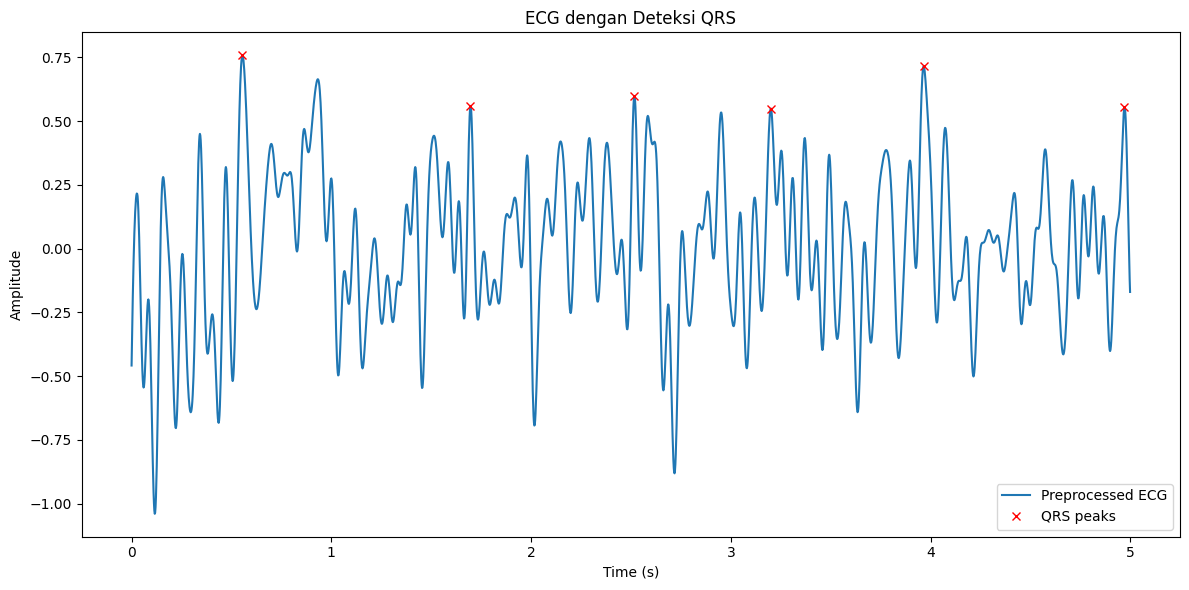

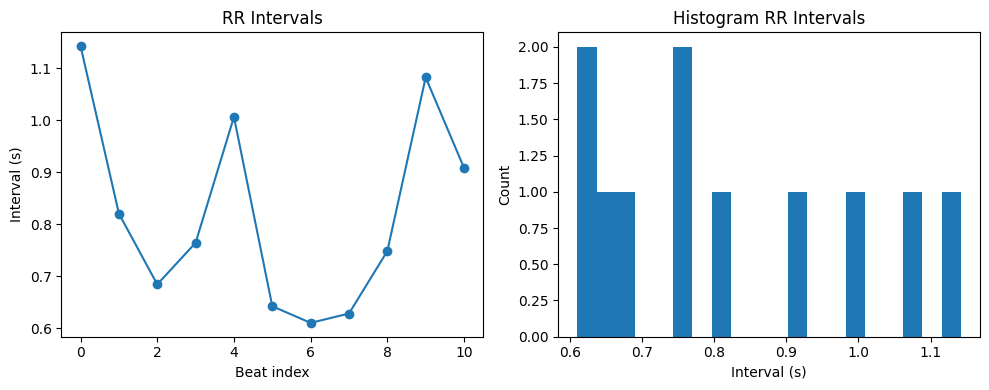

HRV features exported to hrv_features.csv


In [ ]:
def detect_qrs(ecg_pre, fs, distance_sec=0.6, height=None):
    distance = int(distance_sec * fs)
    peaks, props = signal.find_peaks(ecg_pre, distance=distance, height=height)
    times = peaks / fs
    return peaks, times, props.get('peak_heights', None)

def compute_rr_intervals(peaks, fs):
    rr_samples = np.diff(peaks)
    rr_intervals = rr_samples / fs
    return rr_intervals


def compute_hrv_features(rr_intervals):
    nn = rr_intervals
    mean_nn = np.mean(nn)
    sdnn = np.std(nn, ddof=1)
    rmssd = np.sqrt(np.mean(np.diff(nn)**2))
    nn50 = np.sum(np.abs(np.diff(nn)) > 0.05)
    pnn50 = 100 * nn50 / len(nn)
    return {
        'mean_NN_s': mean_nn,
        'SDNN_s': sdnn,
        'RMSSD_s': rmssd,
        'pNN50_%': pnn50
    }


def plot_ecg_with_qrs(ecg_pre, peaks, fs, start_sec=0, duration_sec=5):
    idx0 = int(start_sec * fs)
    idx1 = idx0 + int(duration_sec * fs)
    t = np.arange(idx0, idx1) / fs

    plt.figure(figsize=(12, 6))
    plt.plot(t, ecg_pre[idx0:idx1], label='Preprocessed ECG')
    sel = (peaks >= idx0) & (peaks < idx1)
    plt.plot((peaks[sel]-idx0)/fs, ecg_pre[peaks[sel]], 'rx', label='QRS peaks')
    plt.title('ECG dengan Deteksi QRS')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_rr_and_hist(rr_intervals):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(rr_intervals, marker='o')
    plt.title('RR Intervals')
    plt.xlabel('Beat index')
    plt.ylabel('Interval (s)')

    plt.subplot(1,2,2)
    plt.hist(rr_intervals, bins=20)
    plt.title('Histogram RR Intervals')
    plt.xlabel('Interval (s)')
    plt.ylabel('Count')

    plt.tight_layout()
    plt.show()


def export_hrv_features(features, path='hrv_features.csv'):
    df = pd.DataFrame([features])
    df.to_csv(path, index=False)
    print(f"HRV features exported to {path}")


if __name__ == '__main__':
    try:
        from google.colab import drive; drive.mount('/content/drive')
    except ImportError:
        pass

    csv_path = '/content/drive/MyDrive/Dataset modul 8-9/ecg.csv'
    ecg_raw, fs = load_ecg_from_csv(csv_path, fs=500)
    ecg_pre = preprocess_ecg(ecg_raw, fs, sg_window=31, sg_poly=3)
    peaks, peak_times, _ = detect_qrs(ecg_pre, fs, distance_sec=0.6)
    rr_intervals = compute_rr_intervals(peaks, fs)
    features = compute_hrv_features(rr_intervals)
    print("HRV Features:", features)
    plot_ecg_with_qrs(ecg_pre, peaks, fs)
    plot_rr_and_hist(rr_intervals)
    export_hrv_features(features)
